In [ ]:
from IPython.display import Image
from IPython.display import Video

# L'argument width suffit, les contrôles s'affichent automatiquement
Video("ma_capture.mp4", width=700)

# Interface d'entrée/sortie numérique

Pour que le microcontrôleur interagisse avec son environnement physique, il utilise son périphérique appelé GPIO (*General Purpose Input Output*). C'est une interface entre le processeur et les broches physiques. Nous allons apprendre à les configurer et à les utiliser pour envoyer des signaux électriques.

Une broche peut fonctionner soit en entrée quand elle reçoit une tension, soit en sortie quand elle envoie une tension. Dans ces deux cas précis, ces broches fonctionnent en mode numérique, c'est-à-dire avec deux niveaux de tension :

- 0V correspondant à l'état bas (masse / GND), pas de tension.
- +3.3V correspondant à l'état haut (tension native du STM32).

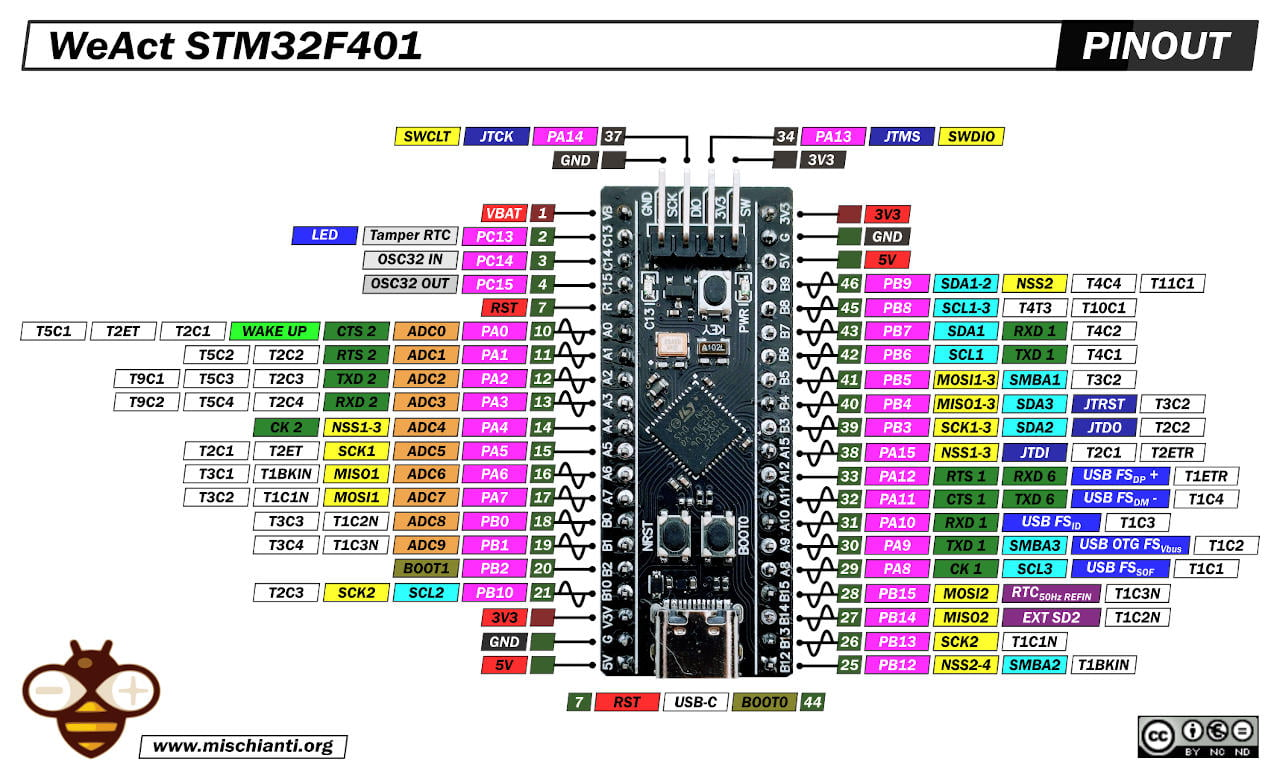

In [34]:
from IPython.display import Image
Image(filename='blackpill.jpg') # Afficher l'image

## Structure d'un port GPIO

chapitre 8 - 7 du datasheet RM0383 Reference manual STM32F411xC/E advanced Arm®-based 32-bit MCUs

Pour configurer ces fonctionnalités sur le microcontrôleur, le STM32F401 possède trois ports de 16 broches (Port A, B, C) gérés par des registres internes de 32 bits dédiés. Nous avons 4 principaux registres pour configurer et manipuler une broche :
- `MODER` (*Mode Register*) : Configure la direction de chaque broche (00: Entrée, 01: Sortie, 10: Fonction alternative, 11: Analogique). Dans ce registre de configuration, chaque broche utilise 2 bits consécutif, ce qui nécessite un décalage de (`broche * 2`).
- `IDR` (*Input Data Register*) : Lit la tension numérique présente sur la broche (1 bit par broche) lorsque la broche est en mode entrée.
- `ODR` (*Output Data Register*) : Définit le niveau logique de sortie (0V ou +3.3V) lorsque la broche est en mode sortie. Utilise 1 bit par broche.
- `BSRR` (*Bit Set/Reset Register*)	: Permet de modifier l’état de manière atomique en une seule écriture. On peut positionner un bit à 1 (Set) ou à 0 (Reset) sans affecter les autres bits. C’est plus sûr en environnement multitâche ou avec interruptions.

Pourque ces registres focntionne, on doit impérativement activer l'horloge du port via le registre `RCC->AHB1ENR` avant de manipuler ces registres.

Sur la carte choisie a utiliser dans ce cours, nous avons 32 broches d'Entree/Sortie numerique :
- Port A : 13 broches disponibles (PA0 à PA12)
- Port B : 14 broches disponibles (PB0 à PB10, et PB12 à PB15).
- Port C : 3 broches disponibles (PC13, PC14, PC15). la broche PC13 est connectée en interne à la LED bleue de la carte; PC14 et PC15 sont reliées au quartz basse fréquence (32.768 kHz).

In [39]:
import pandas as pd
from IPython.display import display, HTML

# 1. Définition des colonnes de bits (de 31 à 0)
colonnes_bits = [f"Bit {i}" for i in range(31, -1, -1)]

# --- FONCTIONS DE GÉNÉRATION DES CHAMPS ---
def get_moder_content():
    return [f"P{bit//2}[{'H' if bit%2 != 0 else 'L'}]" for bit in range(31, -1, -1)]

def get_bsrr_content():
    return [f"BR{bit-16}" if bit >= 16 else f"BS{bit}" for bit in range(31, -1, -1)]

def get_io_content(prefix):
    return ["Réservé (0)" if bit >= 16 else f"{prefix}{bit}" for bit in range(31, -1, -1)]

# --- FONCTION DE STYLISATION COMMUNE ---
def styliser_bloc(df, titre):
    styler = df.style.set_caption(f"<h3 style='color: #2c3e50; text-align: left; margin-top: 20px;'>{titre}</h3>")
    
    styler.set_table_styles([
        {'selector': 'table', 'props': [('border-collapse', 'collapse'), ('width', '100%'), ('font-family', 'monospace'), ('margin-bottom', '30px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('text-align', 'center'), ('padding', '5px'), ('font-size', '10px'), ('border', '1px solid #34495e')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '6px'), ('font-size', '11px'), ('border', '1px solid #bdc3c7')]},
        {'selector': 'th.row_heading', 'props': [('background-color', '#34495e'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left'), ('font-size', '12px'), ('min-width', '120px')]}
    ])
    
    def colorer_cellules(val):
        val_str = str(val)
        if "Réservé" in val_str:
            return 'background-color: #f8f9fa; color: #95a5a6; font-style: italic;'
        elif val_str.startswith("BR"):
            return 'background-color: #fce4d6; color: #c65911; font-weight: bold;'  # Orange/Rouge pour Reset
        elif val_str.startswith("BS"):
            return 'background-color: #e2efda; color: #375623; font-weight: bold;'  # Vert pour Set
        elif "H]" in val_str:
            return 'background-color: #e8f4f8; color: #1f4e78;'
        elif "L]" in val_str:
            return 'background-color: #ebf5fb; color: #2e75b6;'
        elif val_str.startswith("IDR"):
            return 'background-color: #fff2cc; color: #7f6000;'  # Jaune pour la lecture d'entrée
        elif val_str.startswith("ODR"):
            return 'background-color: #fce4d6; color: #a51d24;'  # Rouge clair pour la commande de sortie
        return 'background-color: #ffffff; color: #2c3e50;'

    styler.applymap(colorer_cellules)
    return styler

# =============================================================================
# BLOC 1 : CONFIGURATION & MODIFICATION ATOMIQUE (MODER & BSRR)
# =============================================================================
data_bloc1 = {
    "GPIOx_MODER": get_moder_content(),
    "GPIOx_BSRR": get_bsrr_content()
}
df_bloc1 = pd.DataFrame.from_dict(data_bloc1, orient='index', columns=colonnes_bits)
display(styler_bloc1)

# =============================================================================
# BLOC 2 : LECTURE & ÉCRITURE DES DONNÉES (IDR & ODR)
# =============================================================================
data_bloc2 = {
    "GPIOx_IDR": get_io_content("IDR"),
    "GPIOx_ODR": get_io_content("ODR")
}
df_bloc2 = pd.DataFrame.from_dict(data_bloc2, orient='index', columns=colonnes_bits)
display(styler_bloc2)


,Bit 31,Bit 30,Bit 29,Bit 28,Bit 27,Bit 26,Bit 25,Bit 24,Bit 23,Bit 22,Bit 21,Bit 20,Bit 19,Bit 18,Bit 17,Bit 16,Bit 15,Bit 14,Bit 13,Bit 12,Bit 11,Bit 10,Bit 9,Bit 8,Bit 7,Bit 6,Bit 5,Bit 4,Bit 3,Bit 2,Bit 1,Bit 0
GPIOx_MODER,P15[H],P15[L],P14[H],P14[L],P13[H],P13[L],P12[H],P12[L],P11[H],P11[L],P10[H],P10[L],P9[H],P9[L],P8[H],P8[L],P7[H],P7[L],P6[H],P6[L],P5[H],P5[L],P4[H],P4[L],P3[H],P3[L],P2[H],P2[L],P1[H],P1[L],P0[H],P0[L]
GPIOx_BSRR,BR15,BR14,BR13,BR12,BR11,BR10,BR9,BR8,BR7,BR6,BR5,BR4,BR3,BR2,BR1,BR0,BS15,BS14,BS13,BS12,BS11,BS10,BS9,BS8,BS7,BS6,BS5,BS4,BS3,BS2,BS1,BS0


,Bit 31,Bit 30,Bit 29,Bit 28,Bit 27,Bit 26,Bit 25,Bit 24,Bit 23,Bit 22,Bit 21,Bit 20,Bit 19,Bit 18,Bit 17,Bit 16,Bit 15,Bit 14,Bit 13,Bit 12,Bit 11,Bit 10,Bit 9,Bit 8,Bit 7,Bit 6,Bit 5,Bit 4,Bit 3,Bit 2,Bit 1,Bit 0
GPIOx_IDR,Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),IDR15,IDR14,IDR13,IDR12,IDR11,IDR10,IDR9,IDR8,IDR7,IDR6,IDR5,IDR4,IDR3,IDR2,IDR1,IDR0
GPIOx_ODR,Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),Réservé (0),ODR15,ODR14,ODR13,ODR12,ODR11,ODR10,ODR9,ODR8,ODR7,ODR6,ODR5,ODR4,ODR3,ODR2,ODR1,ODR0


## Configuration d'une sortie numérique : Clignotant

Configuration de la broche 13 du Port C (PC13)

Pour modifier un registre sans altérer les autres broches du meme port, nous utilisons les opérateurs de masquage binaire (`<<`, `|`, `&`, `~`).

Le mode sortie correspond à la configuration `01`. On force d'abord les deux bits de `PC13` à `00`, puis on applique `01`.

```c
GPIOC->MODER &= ~(3UL << (13 * 2)); // Force les bits 27 et 26 de MODER à 0
GPIOC->MODER |=  (1UL << (13 * 2)); // Écrit 01 : Configure PC13 en Sortie
```

Pour l'ecriture en sortie sur PC13

```c
GPIOC->ODR |=  (1UL << 13); // Sortie à +3.3V (HIGH)
GPIOC->ODR &= ~(1UL << 13); // Sortie à 0V (LOW)
```

Sur la carte bluepill la LED utilisateur est connectée à la broche PC13.
Sur ARM, l'horloge du périphérique GPIO doit être activée dans le registre `RCC` (*Reset and Clock Control*) avant de pouvoir écrire dans ses registres.

### Hello World ! Blink

```c
#include "stm32f4xx.h" // Bibliothèque CMSIS standard pour les registres du STM32F4

// Fonction de délai rudimentaire pour le Bare-Metal 
void delay_ms(uint32_t ms) 
{
    // Le STM32F401 tourne par défaut à 16 MHz via son oscillateur interne (HSI)
    // Cette boucle procure un délai très approximatif
    for (uint32_t i = 0; i < ms * 1600; i++) {
        __NOP(); // Instruction assembleur "No Operation" (ne fait rien)
    }
}

int main(void) 
{
    /* 1. INITIALISATION : Activation de l'horloge pour le Port C */
    // Le Port C est connecté au bus AHB1. On active le bit 2 (GPIOCEN) du registre AHB1ENR.
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOCEN; 

    /* 2. CONFIGURATION : Configuration de PC13 en mode Sortie */
    // On réinitialise les bits 27 et 26 de GPIOC->MODER dédiés à PC13
    GPIOC->MODER &= ~(3UL << (13 * 2));  
    // On écrit 01 sur ces bits pour activer le mode sortie générale
    GPIOC->MODER |=  (1UL << (13 * 2));  

    /* 3. ÉTAT INITIAL : LED éteinte (0V) */
    GPIOC->ODR &= ~(1UL << 13); 

    /* 4. BOUCLE PRINCIPALE */
    while(1)
    {
        GPIOC->ODR |= (1UL << 13);  // LED ON (+3.3V)
        delay_ms(1000);            // Délai de 1s
        
        GPIOC->ODR &= ~(1UL << 13); // LED OFF (0V)
        delay_ms(1000);            // Délai de 1s
    }
    
    return 0; // Bonne pratique en C, bien que jamais atteint ici
}

```

### Usage du registre `BSRR`

Cet usage est dédié uniquement à l'écriture, fonctionnant de manière atomique en un seul cycle d'horloge, sans risque de conflit avec d'autres bits du registre.

Il est divisé en deux parties de 16 bits :

- Bits 0 à 15 (Set) : Écrire un `1` met la broche correspondante à l'état haut (+3.3V). Écrire `0` ne fait rien.
- Bits 16 à 31 (Reset) : Écrire un `1` met la broche correspondante à l'état bas (0V). Écrire `0` ne fait rien.

### Hello World ! Blink

```c
#include "stm32f4xx.h" // Bibliothèque CMSIS standard pour les registres du STM32F4

// Fonction de délai rudimentaire pour le Bare-Metal 
void delay_ms(uint32_t ms) 
{
    // Le STM32F401 tourne par défaut à 16 MHz via son oscillateur interne (HSI)
    for (uint32_t i = 0; i < ms * 1600; i++) {
        __NOP(); // Instruction assembleur "No Operation"
    }
}

int main(void) 
{
    /* 1. INITIALISATION : Activation de l'horloge pour le Port C */
    RCC->AHB1ENR |= RCC_AHB1ENR_GPIOCEN; 

    /* 2. CONFIGURATION : Configuration de PC13 en mode Sortie */
    // On réinitialise les bits 27 et 26 de GPIOC->MODER dédiés à PC13
    GPIOC->MODER &= ~(3U << (13 * 2));  
    // CORRECTION : Utilisation de |= pour NE PAS écraser le reste du registre MODER
    GPIOC->MODER |=  (1U << (13 * 2));  

    while(1)
    {
        // ALLUMER LA LED (Mise à l'état LOW / 0V)
        GPIOC->BSRR = (1U << (13 + 16));  // Partie "Reset" du BSRR
        delay_ms(1000);                   // Délai de 1s

        // ÉTEINDRE LA LED (Mise à l'état HIGH / 3.3V)
        GPIOC->BSRR = (1U << 13);         // Partie "Set" du BSRR
        delay_ms(1000);                   // Délai de 1s
    }
    
    return 0; 
}


```

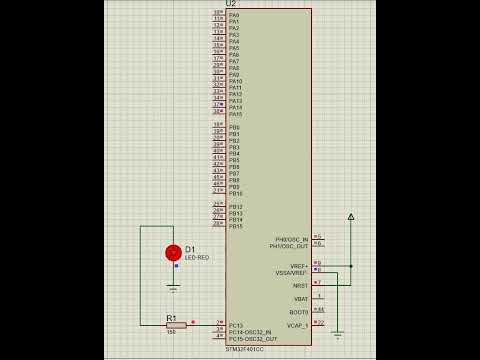

In [3]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('PHbmekj2W7c', width=800, height=450)

## Configuration d'une entrée numérique : Lecture bouton pour contrôler la LED

Pour utiliser une broche en entrée numérique, il est indispensable d'utiliser une résistance de tirage afin d'éviter que la broche ne reste "flottante" (soumise aux parasites électromagnétiques).

Dans ce mode entrée, on va ajouter un autre registre `PUPDR` (*GPIO Port Pull-up/Pull-down Register*) qui gère les résistances internes. Chaque broche occupe 2 bits (`00`: Pas de résistance, `01`: Résistance de Pull-up, `10`: Résistance de Pull-down). 

Le mode entrée correspond à `00` dans le registre `MODER`. L'activation de la résistance Pull-up correspond à `01` dans `PUPDR`.

Configuration de la broche 0 du Port A (PA0)

```c
GPIOA->MODER &= ~(3UL << (0 * 2)); // Écrit 00 : Configure PA0 en Entrée
GPIOA->PUPDR &= ~(3UL << (0 * 2)); // Reset les bits de résistance
GPIOA->PUPDR |=  (1UL << (0 * 2)); // Écrit 01 : Active le Pull-up interne sur PA0
```

Dans notre exemple, nous allons configurer la broche `PA0` en entrée avec sa résistance de Pull-up interne. Le bouton reliera la broche à la masse (`GND`) lors de l'appui, faisant basculer l'état à 0V.

```c
if (GPIOA->IDR & (1UL << 0)) {
    /* Teste si la broche PA0 est à l'état haut (+3.3V) */
}
```

Configuration de `PC13` en sortie, et configuration de `PA0` en entrée, et utilisation du registre `BSRR` pour piloter la LED en fonction de l'état du bouton. La LED s'allume à l'état `LOW` et le bouton passe à `LOW` lorsqu'il est enfoncé. De plus, on active la configuration du Pull-Up interne sur `PA0` car la Black Pill n'a pas de résistance physique externe sur ce bouton.

```c
#include "stm32f4xx.h"

int main(void) 
{
    // 1. CONFIGURATION DES HORLOGES (RCC) 
    RCC->AHB1ENR |= (RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOCEN); 

    // 2. CONFIGURATION DE LA LED (PC13) EN SORTIE 
    GPIOC->MODER &= ~(3U << (13 * 2));  
    GPIOC->MODER |=  (1U << (13 * 2));  

    // 3. CONFIGURATION DU BOUTON KEY (PA0) EN ENTRÉE AVEC PULL-UP 
    GPIOA->MODER &= ~(3U << (0 * 2));   
    GPIOA->PUPDR &= ~(3U << (0 * 2));   
    GPIOA->PUPDR |=  (1U << (0 * 2));   

    while(1)
    {
        // CONDITION : Est-ce que le bouton PA0 est enfoncé ? (Logique inversée = 0)
        // On teste si le bit 0 est égal à 0 (Bouton relié à la masse / GND)
        if ((GPIOA->IDR & (1U << 0)) == 0) 
        {
            // 1. On effectue le TOGGLE immédiatement lors de l'appui
            GPIOC->ODR ^= (1U << 13);
				}
    }
    
    return 0;
}

```

**Remarque** : Lorsqu'on presse un bouton mécanique, les contacts métalliques ne se ferment pas instantanément. Ils "rebondissent" durant quelques millisecondes, générant des trains d'impulsions électriques que le processeur (très rapide) interprète comme de multiples appuis. Le resultat de ce test est imprevisible et ne repond toujours pas a l'attente. Pour remedier a cela, nous allons utiliser un algorithme de anti-rebonds logiciel, c'est un filtre. L'algorithme vérifie que le bouton reste dans son nouvel état pendant un temps minimum stable avant de valider l'appui.

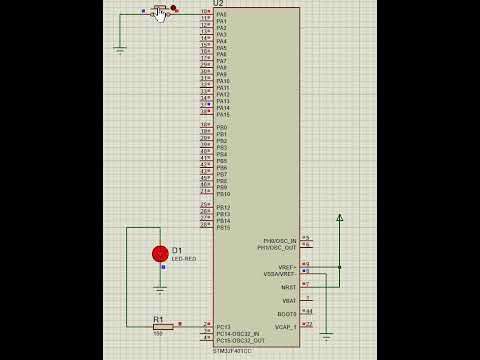

In [9]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('69KC8b_pvTU', width=800, height=450)


## Algorithme anti-rebonds logiciel

Pour remédier à ce problème, nous allons utiliser un algorithme qui consiste à détecter un changement d'état, puis introduire un petit délai logiciel (20 - 50 ms) et par après attendre que le signal se stabilise (filtre temporel), par après tester, vérifier si on a toujours le même état testé lors de l'événement et enfin valider l'état.

```c
#include "stm32f4xx.h"

// Fonction de délai rudimentaire (bloquante)
void delay_ms(uint32_t ms) 
{
    for (uint32_t i = 0; i < ms * 1600; i++) {
        __NOP();
    }
}

int main(void) 
{
    /* CONFIGURATION DES HORLOGES */
    RCC->AHB1ENR |= (RCC_AHB1ENR_GPIOAEN | RCC_AHB1ENR_GPIOCEN); 

    /* CONFIGURATION DE LA LED (PC13) EN SORTIE */
    GPIOC->MODER &= ~(3U << (13 * 2));
    GPIOC->MODER |=  (1U << (13 * 2));

    /* CONFIGURATION DU BOUTON (PA0) EN ENTRÉE AVEC PULL-UP */
    GPIOA->MODER &= ~(3U << (0 * 2));   // Mode Entrée (00)
    GPIOA->PUPDR &= ~(3U << (0 * 2));   // Reset
    GPIOA->PUPDR |=  (1U << (0 * 2));   // Active le Pull-up interne (01)

    while(1)
    {
        // 1. Détection du premier contact (Niveau bas / Bouton pressé à la masse)
        if ((GPIOA->IDR & (1U << 0)) == 0) 
        { 
            delay_ms(20); // 2. Attente de stabilisation (20ms)
            
            // 3. Confirmation : le bouton est-il toujours appuyé ?
            if ((GPIOA->IDR & (1U << 0)) == 0) 
            {
                GPIOC->ODR ^= (1U << 13); // Action validée : basculement de la LED
                
                // 4. Attente du relâchement pour ne pas répéter l'action en boucle
                while ((GPIOA->IDR & (1U << 0)) == 0)
                {
                    __NOP();
                }
            }
        }
    }
    return 0;
}

```


**Remarque** : L'utilisation de `delay_ms()` et des boucles `while()` d'attente est catastrophique pour un système complexe et dans les systèmes temps réel. La fonction `delay_ms()` crée des délais qui arrêtent le CPU durant ce délai, gaspille des millions de cycles d'horloge. Le CPU est occupé à 100% à ne rien faire d'autre (No Operation), exécute du vide (`__NOP()`), ce qui n'est pas souhaité dans la concurrence des tâches. 

Quand on a plusieurs tâches concurrentes et parmi elles certaines qui doivent être temps réel, utiliser la fonction de délai bloquante `delay_ms()` est critique. Si un événement urgent survient pendant un `delay_ms(1000)`, le système est "complètement aveugle" et ne répondra qu'après la fin du délai. 

Pour résoudre cela, nous allons introduire un autre mécanisme pour exécuter nos tâches de manière concurrente en utilisant des** Timers** et des **Interruptions**. Les Timers matériels vont aider à créer des délais non bloquants en comptant le temps en arrière-plan de manière autonome, tandis que les interruptions (`EXTI`) forceront le CPU à répondre immédiatement et instantanément aux événements physiques urgents (comme l'appui sur notre bouton), sans jamais bloquer le programme principal.



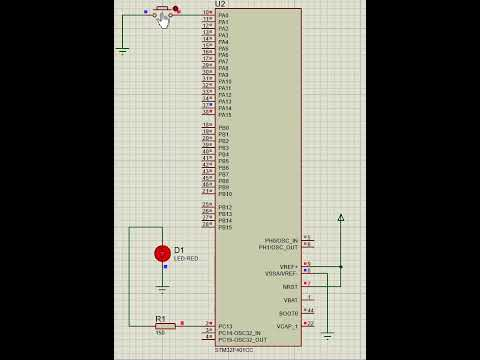

In [11]:
from IPython.display import YouTubeVideo

# Remplacez l'identifiant ci-dessous par celui de votre vidéo
YouTubeVideo('OJzNGNuYUz0', width=800, height=450)
